# Introduction to Deep Learning with Keras and tensorFlow

## Introduction

Keras is an open-source software library that provides a Python interface for artificial neural networks.  It works with TensorFlow, JAX, and PyTorch interchangeably.

Keras, as a high level library, allows to easily define complex ANN architectures to experiment on your data. Keras also supports GPU, which becomes essential for processing huge amount of data and developing machine learning models.  

Among Keras characteristics that make it an attractive option for DL are:
- User friendly, with a simple, consistent interface optimized for common use cases
- Modular and Composable, with easy to connect configutrable building-blocks
- Easy to extend, adding new moduels and classes

## Installation and Setup

Keras runs on top of TensorFlow, which can be installed using pip:

`pip install tensorflow`

Once TensorFlow is installed, Keras can be accessed directly as `tensorflow.keras`.

### Keras with Multiple Backends: JAX, TensorFlow, and PyTorch

Starting with **Keras 3**, the Keras API supports running the same code with different computation engines called *backends*. You can choose between:

- `"tensorflow"` → uses TensorFlow as the backend.
- `"jax"` → uses JAX, a high-performance numerical computing library from Google.
- `"torch"` → uses PyTorch as the backend.

### What is a backend?

The *backend* is the engine that performs the mathematical operations and model training. In earlier versions, Keras relied only on TensorFlow (via `tensorflow.keras`). Now, you can switch backends without changing your model code.

### What does “backend-agnostic” mean?

It means that the code you write using `keras.Model`, `keras.layers.Dense`, etc., **works the same regardless of the backend**. You can swap the backend and the entire notebook will still run without changes.

### How to set the backend

You can set the backend in your script using:

```python
import keras
keras.config.set_backend("tensorflow")  # or "jax" or "torch"



## The problem to solve

In this lab we build a simple Convolutional Neural Network to classify images using the
CIFAR-10 dataset.

The CIFAR-10 dataset is a collection of images commonly used for training machine learning and computer vision models.

It consists of 60000 color images divided into 10 different classes. Each image is 32 by 32 pixels in size and has three color channels red, green, and blue.

The dataset is split into 50000 training images and 10000 test images.

The 10 classes represent different object categories:
airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck.

CIFAR-10 is widely used as a benchmark for image classification tasks due to its manageable size and variety of image content.

## Keras Workflow Overview

Keras follows a simple and consistent workflow that makes it easy to build and train deep learning models. Below are the typical steps you will follow when working with Keras:

1. **Importing libraries and loading data**  
   Load and preprocess the dataset, including normalization and label encoding if needed.

2. **Defining the model**  
   Choose the model architecture using either the Sequential or Functional API, and add layers.

3. **Compiling the model**  
   Specify the loss function, optimizer, and evaluation metrics.

4. **Training the model**  
   Use the `fit()` method to train the model with training data. You can also include validation data, callbacks, and early stopping.

5. **Evaluating the model**  
   Use the `evaluate()` method to measure performance on a test set.

6. **Making predictions**  
   Use the `predict()` method on new or unseen data.

7. **Saving and loading the model**  
   Save your trained model to reuse later or deploy it in production.

8. **(Optional) Tuning and visualization**  
   Monitor training progress with plots or tools like TensorBoard, and tune hyperparameters for better performance.

## Step 1a: Import Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import os
import datetime


 ## Step 1b: Load Data

In [1]:

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values to the range [0, 1]
x_train, x_test = x_train / 255.0, x_test / 255.0

# Convert class labels to one-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

NameError: name 'cifar10' is not defined

## Step 2: Define the Model

We define a simple convolutional neural network using the Keras Sequential API. The model includes convolutional and pooling layers, followed by dense layers.



In [12]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 classes
])

## Step 3: Compile the Model

We compile the model using the Adam optimizer, categorical crossentropy loss (since we have multiple classes), and accuracy as our evaluation metric.


In [13]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


## Step 3b: Set Up Callbacks (Early Stopping, Checkpointing, TensorBoard)

We add:
- **EarlyStopping** to prevent overfitting.
- **ModelCheckpoint** to save the best model.
- **TensorBoard** to visualize training metrics.


In [14]:
log_dir = os.path.join("logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

early_stop = tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_cifar10_model.keras", save_best_only=True, monitor="val_accuracy"
)


## Step 4: Train the Model

We train the model using the `fit` method with a validation split, and apply the callbacks we defined earlier.


In [15]:
history = model.fit(
    x_train, y_train_cat,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[tensorboard_callback, early_stop, checkpoint],
    verbose=2
)

# Save the trained model for further use
model.save("cnn_cifar10_model.keras")



Epoch 1/20
704/704 - 57s - 81ms/step - accuracy: 0.4190 - loss: 1.5954 - val_accuracy: 0.5150 - val_loss: 1.3420
Epoch 2/20
704/704 - 57s - 81ms/step - accuracy: 0.5531 - loss: 1.2526 - val_accuracy: 0.5732 - val_loss: 1.2063
Epoch 3/20
704/704 - 55s - 78ms/step - accuracy: 0.6098 - loss: 1.1035 - val_accuracy: 0.6300 - val_loss: 1.0420
Epoch 4/20
704/704 - 82s - 117ms/step - accuracy: 0.6460 - loss: 1.0068 - val_accuracy: 0.6190 - val_loss: 1.0761
Epoch 5/20
704/704 - 81s - 115ms/step - accuracy: 0.6750 - loss: 0.9270 - val_accuracy: 0.6740 - val_loss: 0.9465
Epoch 6/20
704/704 - 83s - 118ms/step - accuracy: 0.6981 - loss: 0.8651 - val_accuracy: 0.6898 - val_loss: 0.9185
Epoch 7/20
704/704 - 81s - 115ms/step - accuracy: 0.7199 - loss: 0.8058 - val_accuracy: 0.7020 - val_loss: 0.8644
Epoch 8/20
704/704 - 83s - 118ms/step - accuracy: 0.7350 - loss: 0.7640 - val_accuracy: 0.7022 - val_loss: 0.8736
Epoch 9/20
704/704 - 81s - 115ms/step - accuracy: 0.7480 - loss: 0.7215 - val_accuracy: 0.7

## Step 5: Evaluate the Model

We evaluate the model on the test set to obtain final loss and accuracy.

In [17]:
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")


313/313 - 4s - 11ms/step - accuracy: 0.6955 - loss: 0.8920

Test accuracy: 0.6955


## Step 6: Make Predictions and Plot Confusion Matrix

We use the model to predict test labels, then plot a confusion matrix to visualize performance across all classes.


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


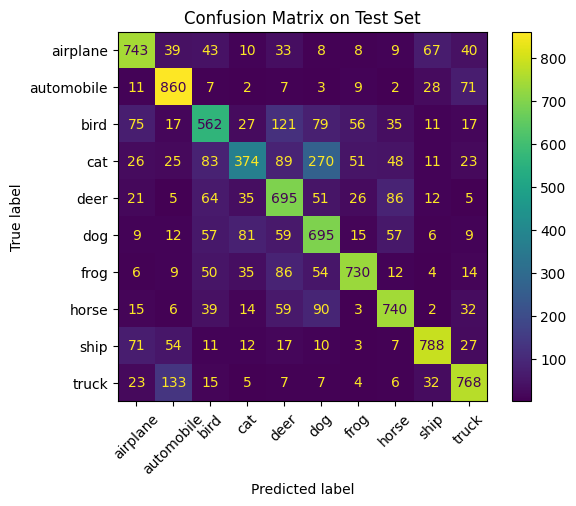

In [18]:


y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test.flatten()

cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[
    'airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck'
])
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix on Test Set")
plt.show()


## Step 8: Visualize Training History

We plot the training and validation accuracy and loss over epochs to understand model learning behavior.


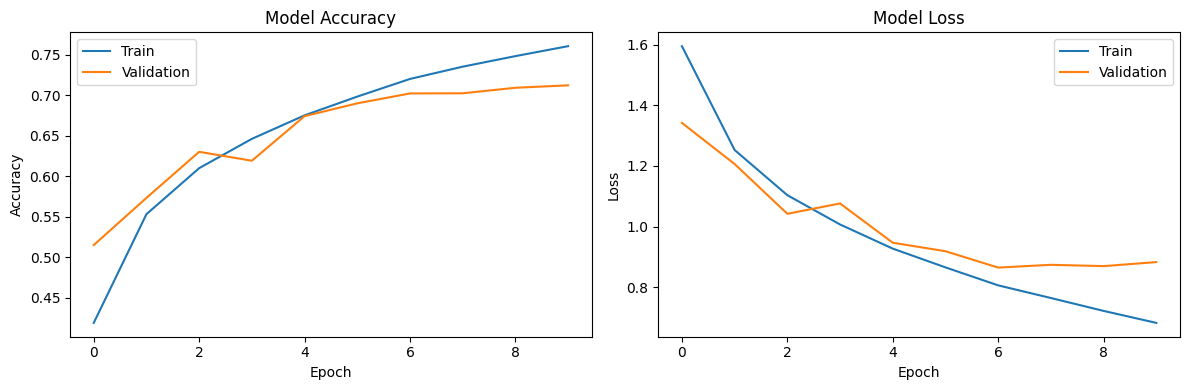

In [19]:

plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

